In [7]:
import numpy as np
import random as ran
import math 
import matplotlib.pyplot as plt

In [8]:
J = 1
N = 20
K = 1

In [9]:


def DH(LATTICE,i,B):
    x1 = i
    x2 = (i + 1)%N
    x3 = (i - 1)%N

    return -2*J*LATTICE[x1]*(LATTICE[x2] + LATTICE[x3]) - 2*B*LATTICE[x1]

def metropolis_step(LATTICE,T,B,i):
    LATTICE[i] = -LATTICE[i]
 
    p = np.exp(-DH(LATTICE,i,B)/(K*T))
    if(p >= np.random.random()):
        return LATTICE
    else:
        LATTICE[i] = -LATTICE[i] # lascialo invariato
        return LATTICE


# Sono interessato a fare vari esperimenti al variare di
# Temperatura e modulo del campo magnetico.
def esperimento(LATTICE, T, B,n_equilibrio = 500, n_misure=200):
    TEMP_LATTICE = LATTICE

    # Equilibrio termico
    for _ in range(n_equilibrio):
        for i in range(N):
            metropolis_step(LATTICE,T,B,i)
    
    misure = []
    for _ in range(n_misure):
        for i in range(N):
            TEMP_LATTICE = metropolis_step(TEMP_LATTICE,T,B,i)
        misure.append(abs(np.mean(TEMP_LATTICE)))

    return np.mean(misure),TEMP_LATTICE


    

/tmp/ipykernel_8061/227969051.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  p = np.exp(-DH(LATTICE,i,B)/(K*T))


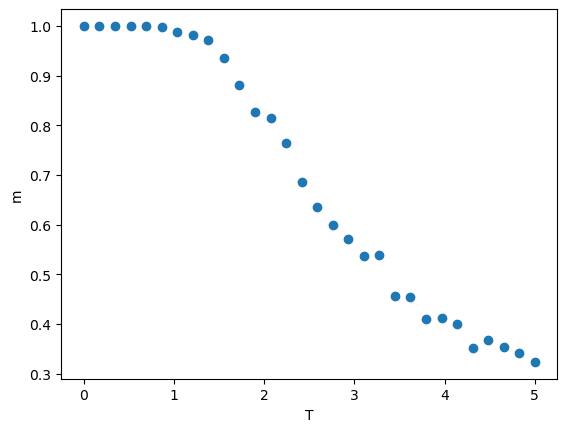

In [10]:

LATTICE = np.random.choice([-1,1],size=(N))
Ts = np.linspace(0, 5.0, 30)
ms = [esperimento(LATTICE, T, 1)[0] for T in Ts]

plt.scatter(Ts, ms)
plt.xlabel("T")
plt.ylabel("m")
plt.show()

Come possiamo vedere dalla seguente simulazione Il modello di ising 1d non ha la rottura della simmetria per B=0

/tmp/ipykernel_8061/227969051.py:11: RuntimeWarning: invalid value encountered in scalar divide
  p = np.exp(-DH(LATTICE,i,B)/(K*T))
/tmp/ipykernel_8061/227969051.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  p = np.exp(-DH(LATTICE,i,B)/(K*T))


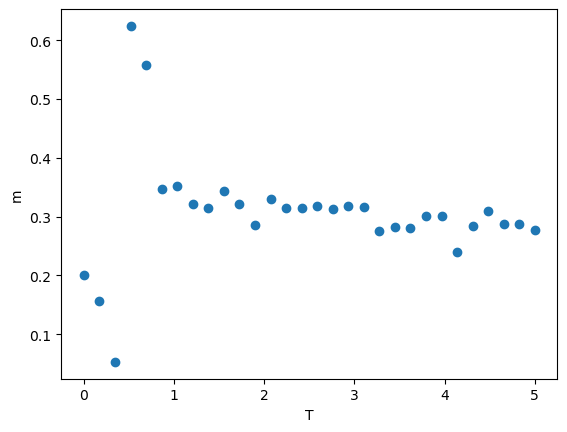

In [ ]:

LATTICE = np.random.choice([-1,1],size=(N))
Ts = np.linspace(0, 5.0, 30)
ms = [esperimento(LATTICE, T, 0)[0] for T in Ts] # B = 0

plt.scatter(Ts, ms)
plt.xlabel("T")
plt.ylabel("m")
plt.show()